In [1]:
import numpy as np
import pandas as pd

In [2]:
data =' https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [3]:
!wget $data

--2026-10-04 14:46:09--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.008s  

2026-10-04 14:46:09 (73.6 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]



In [4]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

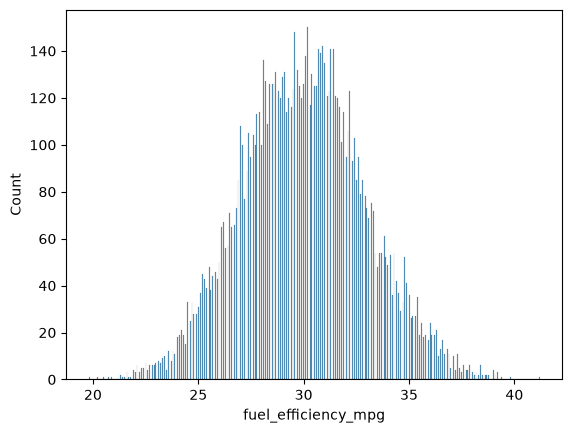

In [6]:
sns.histplot(df.fuel_efficiency_mpg, bins=500)

In [7]:
#fuel_efficiency_mpg hasn't a long tail. It follow a normal distribution

In [8]:
base = ['engine_displacement', 'horsepower',
        'vehicle_weight', 'model_year', 'fuel_efficiency_mpg' 
]
df_small = df[base]
df_small.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [9]:
#Question 1: which columns has null values?

In [10]:
df_small.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [11]:
#What's the median (50% percentile) for variable 'horsepower'

In [12]:
df_small.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [13]:
n = len(df_small)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_small.iloc[idx[:n_train]]
df_val = df_small.iloc[idx[n_train:n_train + n_val]]
df_test = df_small.iloc[idx[n_train + n_val:]]

In [14]:
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

Question 3
We need to deal with missing values for the column from Q1.
We have two options: fill it with 0 or with the mean of this variable.
Try both options. For each, train a linear regression model without regularization using the code from the lessons.
For computing the mean, use the training only!
Use the validation dataset to evaluate the models and compare the RMSE of each option.
Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
Which option gives better RMSE?

In [15]:
def prepare_X(df):
    df= df.copy()
    features = base.copy()
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [16]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ ones, X])
    XTX = X.T.dot(X)
    XTX_i= np.linalg.inv(XTX)

    w_full = XTX_i.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [17]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error**2
    mse = se.mean()
    return np.sqrt(mse)

In [18]:
#train
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
#validaton
X_val = prepare_X(df_val)
y_pred= w0 + X_val.dot(w)
#evaluatio
score = rmse(y_val, y_pred)
round(score, 3)

np.float64(0.006)

In [19]:
def prepare_X_fillmean(df):
    df= df.copy()
    features = base.copy()
    
    df_num = df[features]
    df_num = df_num.fillna(254.446016)
    X = df_num.values
    return X

In [20]:
#train
X_train = prepare_X_fillmean(df_train)
w0, w = train_linear_regression(X_train, y_train)
#validaton
X_val = prepare_X_fillmean(df_val)
y_pred= w0 + X_val.dot(w)
#evaluatio
score = rmse(y_val, y_pred)
round(score, 3)

np.float64(0.006)

Question 4
Now let's train a regularized linear regression.
For this question, fill the NAs with 0.
Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
Use RMSE to evaluate the model on the validation dataset.
Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
Which r gives the best RMSE?
If multiple options give the same best RMSE, select the smallest r.

In [21]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r*np.eye(XTX.shape[0])
    XTX_i= np.linalg.inv(XTX)

    w_full = XTX_i.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [22]:
for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r)
    #validaton
    X_val = prepare_X(df_val)
    y_pred= w0 + X_val.dot(w)
    #evaluatio
    score = rmse(y_val, y_pred)
    print(r, round(score, 6))

0.0 0.006321
0.01 0.006371
0.1 0.007875
1 0.013542
5 0.015316
10 0.015584
100 0.015839


Question 5
We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
For each seed, do the train/validation/test split with 60%/20%/20% distribution.
Fill the missing values with 0 and train a model without regularization.
For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
Round the result to 3 decimal digits (round(std, 3))

In [23]:

for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(i)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df_small.iloc[idx[:n_train]]
    df_val = df_small.iloc[idx[n_train:n_train + n_val]]
    df_test = df_small.iloc[idx[n_train + n_val:]]

    y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
    y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
    y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

    #train
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    #validaton
    X_val = prepare_X(df_val)
    y_pred= w0 + X_val.dot(w)
    #evaluatio
    score = rmse(y_val, y_pred)
    print(score)

0.006521729031322558
0.006077447540716175
0.005913657542479091
0.006331083686299482
0.006126397724650004
0.006379356864517239
0.006727313568705901
0.005988452847674376
0.0061965769195687906
0.006077419005598659


Question 6
Split the dataset like previously, use seed 9.
Combine train and validation datasets.
Fill the missing values with 0 and train a model with r=0.001.
What's the RMSE on the test dataset?

In [24]:
n = len(df_small)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_small.iloc[idx[:n_train]]
df_val = df_small.iloc[idx[n_train:n_train + n_val]]
df_test = df_small.iloc[idx[n_train + n_val:]]

y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

In [25]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop = True)
df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2320,246.0,4100,2014,32.5
1,2230,252.0,4250,1998,33.2
2,2700,276.0,4490,2008,32.4
3,2220,269.0,4060,2004,29.9
4,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
7995,2690,324.0,4510,2023,35.7
7996,1920,190.0,4000,1998,30.8
7997,1800,225.0,3980,1994,29.1
7998,1970,232.0,3560,2009,32.2


In [26]:
y_full_train = np.concatenate([y_train, y_val])
y_full_train
    

array([3.51154544, 3.53222564, 3.5085559 , ..., 3.40452517, 3.50254988,
       3.60004824], shape=(8000,))

In [27]:
X_full_train = prepare_X(df_full_train)
X_full_train

array([[2320. ,  246. , 4100. , 2014. ,   32.5],
       [2230. ,  252. , 4250. , 1998. ,   33.2],
       [2700. ,  276. , 4490. , 2008. ,   32.4],
       ...,
       [1800. ,  225. , 3980. , 1994. ,   29.1],
       [1970. ,  232. , 3560. , 2009. ,   32.2],
       [2180. ,  254. , 3970. , 2018. ,   35.6]], shape=(8000, 5))

In [30]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
w0, w

(np.float64(2.410004642442105),
 array([-3.14122981e-07,  3.94578268e-06, -2.09489677e-06,  2.97939211e-05,
         3.22905098e-02]))

In [31]:
X_test = prepare_X(df_test)
y_pred= w0 + X_test.dot(w)

score = rmse(y_test, y_pred)
score

np.float64(0.006178981391011516)

np.float64(0.006198110676062946)